## Imports

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Polygon
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from scipy.stats import gaussian_kde, rankdata, wilcoxon, zscore
from tqdm.notebook import trange

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import FIG_DIR
from analysis_helpers.functions import mean_center, rankbiserialr, show_source

## Functions

In [2]:
show_source(mean_center)

In [3]:
show_source(rankbiserialr)

In [4]:
def rdp(trajectory, epsilon, metric='cosine', return_indices=False):
    """
    Simplify an n-dimensional trajectory using the Ramer-Douglas-Peucker 
    algorithm.

    Parameters
    ----------
    trajectory : numpy.ndarray
        A (timepoints x features) matrix representing the curve to 
        simplify.
    epsilon : float
        Maximum allowed distance from a point to the simplified curve. 
        Points farther than epsilon from the line segment connecting 
        their neighbors are retained.
    metric : str or callable
        Distance metric used when computing point-to-segment distances.
        Accepts any distance name supported by 
        scipy.spatial.distance.cdist (e.g. 'euclidean', 'cosine', 
        'correlation') or a callable with signature f(u, v) -> float.
    return_indices : bool, default False
        If True, return a tuple (simplified_trajectory, indices) where
        indices is a 1D array of the retained points' indices in the 
        original trajectory. Else return only the simplified trajectory.

    Returns
    -------
    numpy.ndarray or tuple
        The simplified trajectory, or (simplified_trajectory, indices) 
        when return_indices is True.
    """
    def _dist(points, start, end):
        """
        Compute the distance from each point in `points` to the line 
        segment defined by `start` and `end`.

        Perpendicular foot is clamped to the segment so points past
        either endpoint are measured to the nearest endpoint.
        """
        segment = end - start
        seg_len_sq = np.dot(segment, segment)

        if seg_len_sq == 0:
            # Degenerate segment: start == end; distance is point-to-point
            if callable(metric):
                return np.array([metric(p, start) for p in points])
            return cdist(points, start[np.newaxis], metric=metric).ravel()

        # Scalar projection of each point onto the segment, clamped to [0, 1].
        t = np.clip(np.dot(points - start, segment) / seg_len_sq, 0.0, 1.0)
        projections = start + t[:, np.newaxis] * segment

        if callable(metric):
            return np.array(
                [metric(p, proj) for p, proj in zip(points, projections)]
            )
        return cdist(points, projections, metric=metric).diagonal()

    def _rdp_indices(indices):
        """Recursively collect indices of points to keep."""
        if len(indices) <= 2:
            return list(indices)

        start = trajectory[indices[0]]
        end = trajectory[indices[-1]]
        inner = indices[1:-1]

        dists = _dist(trajectory[inner], start, end)
        max_idx = np.argmax(dists)
        max_dist = dists[max_idx]

        if max_dist > epsilon:
            pivot = max_idx + 1
            left = _rdp_indices(indices[:pivot + 1])
            right = _rdp_indices(indices[pivot:])
            # Merge, avoiding the duplicate at the pivot.
            return left[:-1] + right
        
        return [indices[0], indices[-1]]

    trajectory = np.asarray(trajectory)
    kept = _rdp_indices(list(range(len(trajectory))))
    kept = np.array(kept)

    simplified = trajectory[kept]
    return (simplified, kept) if return_indices else simplified

In [5]:
def eps_removal_pos(eps_at_removal, imm_recalled, omitted):
    """
    Probability of superiority for RDP-removability vs omission -- the 
    probability that an event omitted from delayed recall is removed 
    from immediate recall by RDP at a lower epsilon than one retained.
    """
    imm_recalled = list(imm_recalled)
    omitted = list(omitted)
    labels = np.isin(imm_recalled, omitted).astype(int)
    n_pos = labels.sum()
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        raise ValueError(
            'need at least 1 omitted & 1 retained event to compute PoS'
            f'(n_omitted = {n_pos}, n_retained = {n_neg})'
        )
    
    # convert to "prominence" so removed earlier -> higher value 
    prominence = np.array([-eps_at_removal[ev] for ev in imm_recalled])
    ranks = rankdata(prominence)
    return (ranks[labels == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

In [6]:
def fit_logistic(design_mat, outcome):
    """Fit a logistic regression by MLE & return coefficients"""
    def _neg_ll(beta):
        logits = design_mat @ beta
        return np.sum(np.logaddexp(0, logits) - outcome * logits)
 
    return minimize(_neg_ll, np.zeros(design_mat.shape[1]), method='BFGS').x

In [7]:
def draw_rdp_cartoon(ax, aspect):
    """
    Draw the RDP algorithm cartoon for figure panel A.

    The helper functions below essentially reimplement the RDP algorithm
    from to the main rdp() function, but the cartoon needs it own
    implementation to capture the intermediate steps for the figure.
    """

    def _point_segment_distance_2d(points, start, end):
        segment = end - start
        length_sq = float(segment @ segment)
        if length_sq == 0:
            return np.linalg.norm(points - start, axis=1)
        t = np.clip((points - start) @ segment / length_sq, 0, 1)
        projections = start + t[:, None] * segment
        return np.linalg.norm(points - projections, axis=1)

    def _cartoon_final_kept(path, eps):
        def _recurse(indices):
            if len(indices) <= 2:
                return list(indices)
            dists = _point_segment_distance_2d(path[indices[1:-1]], 
                                               path[indices[0]], 
                                               path[indices[-1]])
            farthest = int(np.argmax(dists))
            if dists[farthest] > eps:
                pivot = farthest + 1
                return (_recurse(indices[:pivot + 1])[:-1] + 
                        _recurse(indices[pivot:]))
            return [indices[0], indices[-1]]
        return sorted(_recurse(list(range(len(path)))))

    def _cartoon_recursion_steps(path, eps):
        kept = {0, len(path) - 1}
        dropped = set()
        steps = []

        def _recurse(lo, hi):
            interior = list(range(lo + 1, hi))
            if not interior:
                return
            dists = _point_segment_distance_2d(path[interior], 
                                               path[lo], 
                                               path[hi])
            farthest_local = int(np.argmax(dists))
            farthest = interior[farthest_local]
            keep = dists[farthest_local] > eps
            steps.append({
                'lo': lo,
                'hi': hi,
                'test': farthest,
                'keep': keep,
                'kept': set(kept),
                'dropped': set(dropped)
            })
            if keep:
                kept.add(farthest)
                _recurse(lo, farthest)
                _recurse(farthest, hi)
            else:
                dropped.update(interior)

        _recurse(0, len(path) - 1)
        return steps

    def _epsilon_band_polygon(start, end, eps):
        direction = end - start
        unit = direction / np.linalg.norm(direction)
        normal = np.array([-unit[1], unit[0]])
        return np.array([start + eps * normal, end + eps * normal,
                         end - eps * normal, start - eps * normal])

    def _draw_segment(points, indices, color, lw, ls='-', zorder=1, alpha=1.0):
        pts = points[np.asarray(indices)]
        ax.plot(pts[:, 0], pts[:, 1],
                ls,
                color=color,
                lw=lw,
                alpha=alpha,
                zorder=zorder,
                solid_capstyle='round')

    def _draw_points(points, indices, color, size):
        for i in indices:
            ax.scatter(*points[i],
                       s=size,
                       color=color,
                       edgecolor=MARKER_EDGE_COLOR,
                       lw=CARTOON_POINT_EDGE_LW,
                       zorder=5)

    def _draw_ghost(points, i):
        # add opaque white circle behind removed point to prevent
        # connecting line from showing through
        ax.scatter(*points[i],
                   s=CARTOON_GHOST_SIZE,
                   facecolor='white',
                   edgecolor='white',
                   lw=CARTOON_GHOST_EDGE_LW,
                   zorder=3.5)
        ax.scatter(*points[i],
                   s=CARTOON_GHOST_SIZE,
                   color=CARTOON_GHOST_COLOR,
                   alpha=CARTOON_GHOST_ALPHA,
                   edgecolor=MARKER_EDGE_COLOR,
                   lw=CARTOON_GHOST_EDGE_LW,
                   zorder=4)

    def _draw_ring(points, i, kept):
        ax.scatter(*points[i],
                   s=CARTOON_RING_SIZE,
                   facecolor='none',
                   edgecolor=CARTOON_RING_COLOR,
                   lw=CARTOON_RING_LW,
                   zorder=6)
        ax.scatter(*points[i],
                   s=CARTOON_RING_INNER_SIZE,
                   color=CARTOON_KEEP_COLOR if kept else CARTOON_DROP_COLOR,
                   edgecolor=MARKER_EDGE_COLOR,
                   lw=CARTOON_RING_INNER_EDGE_LW,
                   zorder=7)

    (x_min, y_min) = CARTOON_PATH.min(axis=0)
    (x_max, y_max) = CARTOON_PATH.max(axis=0)
    x_span, y_span = x_max - x_min, y_max - y_min
    x_lo = x_min - CARTOON_PAD_LEFT * x_span
    x_hi = x_max + CARTOON_PAD_RIGHT * x_span

    steps = _cartoon_recursion_steps(CARTOON_PATH, CARTOON_EPS)
    final_kept = _cartoon_final_kept(CARTOON_PATH, CARTOON_EPS)
    final_dropped = [i for i in range(len(CARTOON_PATH)) if i not in final_kept]
    # one row per recursion step + final result
    n_rows = len(steps) + 1

    # vertical extent and per-row center lines
    height = (x_hi - x_lo) / aspect
    mid_y = (y_min + y_max) / 2
    y_top = mid_y + height / 2
    y_bot = mid_y - height / 2
    margin = CARTOON_ROW_MARGIN_FRAC * height
    first_center = y_top - margin - y_span / 2
    last_center = y_bot + margin + y_span / 2
    row_centers = []
    for i in range(n_rows):
        center = first_center - i * (first_center - last_center) / (n_rows - 1)
        row_centers.append(center)

    for row, center in enumerate(row_centers):
        path = CARTOON_PATH + np.array([0.0, center - mid_y])

        if row < len(steps):
            # intermediate simplification steps
            step = steps[row]
            lo, hi, tested, kept = step['lo'], step['hi'], step['test'], step['keep']
            kept_so_far, dropped_so_far = step['kept'], step['dropped']

            # faint copy of the original path
            _draw_segment(path,
                          range(len(CARTOON_PATH)),
                          CARTOON_FAINT_COLOR,
                          CARTOON_FAINT_LW,
                          zorder=0.5,
                          alpha=CARTOON_FAINT_ALPHA)

            # solid curve through the currently retained points
            marks = sorted(set(kept_so_far) | {lo, hi})
            for a, b in zip(marks, marks[1:]):
                interior = list(range(a + 1, b))
                if interior and all(j in dropped_so_far for j in interior):
                    _draw_segment(path,
                                  [a, b],
                                  CARTOON_ENDPOINT_COLOR,
                                  CARTOON_SIMPLIFIED_LW,
                                  zorder=2)
                else:
                    _draw_segment(path,
                                  range(a, b + 1),
                                  CARTOON_CURVE_COLOR,
                                  CARTOON_CURVE_LW,
                                  zorder=1)

            # epsilon band + chord for the segment currently being tested
            band = _epsilon_band_polygon(path[lo], path[hi], CARTOON_EPS)
            band_patch = Polygon(band,
                                 closed=True,
                                 facecolor=CARTOON_BAND_COLOR,
                                 edgecolor='none',
                                 alpha=CARTOON_BAND_ALPHA,
                                 zorder=0)
            ax.add_patch(band_patch)
            ax.plot([path[lo, 0], path[hi, 0]],
                    [path[lo, 1], path[hi, 1]],
                    color=CARTOON_CHORD_COLOR,
                    lw=CARTOON_CHORD_LW,
                    zorder=0.3,
                    solid_capstyle='round')

            for j in range(len(CARTOON_PATH)):
                if j in dropped_so_far:
                    _draw_ghost(path, j)
                elif j in kept_so_far or j in (lo, hi):
                    _draw_points(path, 
                                 [j], 
                                 CARTOON_ENDPOINT_COLOR, 
                                 CARTOON_POINT_SIZE)
                else:
                    _draw_points(path, 
                                 [j], 
                                 CARTOON_CURVE_COLOR, 
                                 CARTOON_POINT_SIZE)
            # highlight the point being tested
            _draw_ring(path, tested, kept)

        else:
            # final step, fully simplified path
            _draw_segment(path, 
                          range(len(CARTOON_PATH)), 
                          CARTOON_FAINT_COLOR,
                          CARTOON_FAINT_LW, 
                          zorder=0, 
                          alpha=CARTOON_FAINT_ALPHA)
            _draw_segment(path, 
                          final_kept, 
                          CARTOON_ENDPOINT_COLOR, 
                          CARTOON_SIMPLIFIED_LW, 
                          zorder=2)
            for j in final_dropped:
                _draw_ghost(path, j)
            _draw_points(path, 
                         final_kept, 
                         CARTOON_ENDPOINT_COLOR, 
                         CARTOON_FINAL_POINT_SIZE)

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_bot, y_top)
    ax.set_aspect('equal')
    ax.axis('off')
    return ax

In [8]:
def axes_rect(x, y, w, h, fig_width, fig_height):
    """
    Convert a panel's (x, y, width, height) box in inches to fractions 
    of full figure height/width.
    (laying out fig in inches then converting makes it easier to align 
    cartoon steps with panel grid rows)
    """
    return [x / fig_width, y / fig_height, w / fig_width, h / fig_height]

In [9]:
def draw_regression_null(ax, null_samples, bin_edges, side, color):
    """
    Draw one side of the regression panel's permutation-null 
    distribution.
    """
    counts = np.histogram(null_samples, bins=bin_edges)[0]
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    heights = np.diff(bin_edges)
    width = counts / counts.max() * REG_NULL_HALF_WIDTH
    ax.barh(centers, 
            side * width, 
            height=heights, 
            color=color,
            alpha=REG_NULL_FILL_ALPHA, 
            lw=0, 
            align='center')
    return ax

In [10]:
def add_panel_letter(ax, label, position):
    """Add a letter label to a panel's axes"""
    ax.text(*position, 
            label, 
            transform=ax.transAxes, 
            fontsize=PANEL_LETTER_SIZE,
            fontweight=PANEL_LETTER_WEIGHT, 
            va='bottom', 
            ha='left',
            color=PANEL_LETTER_COLOR, 
            zorder=30)
    return ax

In [11]:
def draw_event_dot(ax, xy, episode_event, alpha=1.0, zorder=3):
    """Draw event dots for the example participant panel"""
    ax.scatter(xy[0], xy[1], 
               s=EXAMPLE_DOT_SIZE, 
               color=EXAMPLE_EPISODE_COLORS[int(episode_event)],
               edgecolor=EXAMPLE_DOT_EDGE_COLOR, 
               lw=EXAMPLE_DOT_EDGE_LW, 
               alpha=alpha, 
               zorder=zorder)
    return ax

## Load data

In [12]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

In [13]:
N_BOOTS_CI = 10_000
N_PERMS_P = 10_000

In [14]:
ep_events_centered = mean_center(atlep1.events)

# center immediate & delayed recall on mean centroid to mitigate 
# person-specific register effects (idiolect, etc.)
imm_events_centered = []
del_events_centered = []
for p in participants:
    imm_centered, del_centered = mean_center(p.events['atlep1'], p.events['delayed'])
    imm_events_centered.append(imm_centered)
    del_events_centered.append(del_centered)

In [15]:
EPSILONS = np.arange(0, 2.1, 0.1).round(1)

rdp_data = []
for p_ix, p in enumerate(participants):
    imm_events = imm_events_centered[p_ix]
    imm_matches = p.event_matches['atlep1']
    del_matches = p.event_matches['delayed']
    
    # sweep over epsilons, record lowest at which each event is removed
    eps_at_removal = {}
    prev_retained = set(range(len(imm_events)))
    
    for eps in EPSILONS[1:].tolist():
        new_retained = set(rdp(imm_events, 
                               epsilon=eps, 
                               metric='cosine', 
                               return_indices=True)[1].tolist())
        if new_retained != prev_retained:
            for removed_event in prev_retained - new_retained:
                matched_ep_event = imm_matches[removed_event].item()
                eps_at_removal.setdefault(matched_ep_event, eps)
            prev_retained = new_retained
    
    # confirm all interior events were removed at some epsilon
    assert len(new_retained) == 2
    
    # RDP can't remove 1st or last events recalled, so exclude from pool
    imm_counts = Counter(imm_matches[1:-1].tolist())
    del_counts = Counter(del_matches.tolist())
    imm_endpoint_counts = Counter((int(imm_matches[0]), int(imm_matches[-1])))
    omitted = set(imm_counts - (del_counts - imm_endpoint_counts))
    
    rdp_data.append({
        'eps_at_removal': eps_at_removal,
        'omitted': omitted,
        'pool': set(imm_matches[1:-1].tolist())
    })

## Does RDP-removability from immediate recall predict omission from delayed recall?

In [16]:
participants_pos = []

for p_data in rdp_data:
    if len(p_data['omitted']) == 0:
        # need at least 1 omitted event to cmopute PoS
        continue
    
    pos = eps_removal_pos(p_data['eps_at_removal'], 
                          p_data['pool'], 
                          p_data['omitted'])
    participants_pos.append(pos)
    
participants_pos = np.array(participants_pos)

T, p = wilcoxon(participants_pos, 0.5, alternative='two-sided', method='exact')
rb = rankbiserialr(participants_pos, 0.5)

pos_boot_means = []
rng = np.random.default_rng(0)
for boot in range(N_BOOTS_CI):
    boot_ixs = rng.integers(0, len(participants_pos), len(participants_pos))
    pos_boot_means.append(participants_pos[boot_ixs].mean())
    
pos_mean_ci_low, pos_mean_ci_high = np.percentile(pos_boot_means, (2.5, 97.5))

T, p, rb = T.item(), p.item(), rb.item()
pos_mean_ci_low, pos_mean_ci_high = pos_mean_ci_low.item(), pos_mean_ci_high.item()

print(f'mean probability of superiority: {np.mean(participants_pos):.3f}')
print(f'95% CI = [{pos_mean_ci_low:.3f}, {pos_mean_ci_high:.3f}]')
print(f'{T=}, {p=:.4f}, {rb=:.4f}')

mean probability of superiority: 0.576
95% CI = [0.519, 0.632]
T=330.0, p=0.0074, rb=0.4388


## Does RDP-removability from own immediate recall predict omission better than RDP-removability from *other* participants' immediate recalls?

In [17]:
own_win_rates = []
# additional values needed for top-k curve in fig
target_n_losses = []
target_n_ties = []
target_n_surrogates = []

for i, p_target in enumerate(rdp_data):
    if len(p_target['omitted']) == 0:
        # need at least 1 omitted event to cmopute PoS
        continue

    target_eps_at_removal = p_target['eps_at_removal']
    target_omitted = p_target['omitted']
    
    tn_wins = tn_ties = tn_losses = 0
    for j, p_surrogate in enumerate(rdp_data):
        if i == j:
            continue
            
        # episode events both target and surrogate immediately recalled
        shared_pool = p_target['pool'] & p_surrogate['pool']
        if len(shared_pool & target_omitted) == 0:
            # surrogate must have immediately recalled at least 1 event 
            # the target participant omitted to compute PoS
            continue
            
        surr_eps_at_removal = p_surrogate['eps_at_removal']        
        pos_target = eps_removal_pos(target_eps_at_removal, 
                                     shared_pool, 
                                     target_omitted)
        pos_surrogate = eps_removal_pos(surr_eps_at_removal, 
                                        shared_pool, 
                                        target_omitted)
        if pos_target > pos_surrogate:
            tn_wins += 1
        elif pos_target == pos_surrogate:
            tn_ties += 1
        else:
            tn_losses += 1
            
    tn_surrogates = tn_wins + tn_ties + tn_losses
    own_win_rates.append((tn_wins + tn_ties * 0.5) / tn_surrogates)
    target_n_losses.append(tn_losses)
    target_n_ties.append(tn_ties)
    target_n_surrogates.append(tn_surrogates)
        
    
own_win_rates = np.array(own_win_rates)
target_n_losses = np.array(target_n_losses)
target_n_ties = np.array(target_n_ties)
target_n_surrogates = np.array(target_n_surrogates)

    
T, p = wilcoxon(own_win_rates, 0.5, alternative='two-sided', method='exact')
rb = rankbiserialr(own_win_rates, 0.5)

win_rate_boot_means = []
rng = np.random.default_rng(0)
for boot in range(N_BOOTS_CI):
    boot_ixs = rng.integers(0, len(own_win_rates), len(own_win_rates))
    win_rate_boot_means.append(own_win_rates[boot_ixs].mean())
    
win_rate_ci_low, win_rate_ci_high = np.percentile(win_rate_boot_means, (2.5, 97.5))

T, p, rb = T.item(), p.item(), rb.item()
win_rate_ci_low, win_rate_ci_high = win_rate_ci_low.item(), win_rate_ci_high.item()

print(f'mean win rate: {np.mean(own_win_rates):.3f}')
print(f'95% CI = [{win_rate_ci_low:.3f}, {win_rate_ci_high:.3f}]')
print(f'{T=}, {p=:.4f}, {rb=:.4f}')

mean win rate: 0.614
95% CI = [0.541, 0.685]
T=311.5, p=0.0041, rb=0.4702


## Is RDP-removability predictiveness specific to own immediate recall geometry rather than episode geometry?

In [18]:
episode_eps_at_removal = {}
prev_retained = set(range(len(ep_events_centered)))
for eps in EPSILONS[1:].tolist():
    new_retained = set(rdp(ep_events_centered,
                           epsilon=eps,
                           metric='cosine',
                           return_indices=True)[1].tolist())
    if new_retained != prev_retained:
        for removed_event in prev_retained - new_retained:
            episode_eps_at_removal[removed_event] = eps
        prev_retained = new_retained

# confirm all events removed at some epsilon
assert len(new_retained) == 2

In [19]:
# construct matrix for regression
participant_ids = []
ep_event_ids = []
own_prominence_z = []
ep_prominence_z = []
omitted_labels = []

for p_ix, p_data in enumerate(rdp_data):
    # ensure 1st & last episode events are excluded if not matched by 
    # 1st & last recall events
    pool = sorted(p_data['pool'] - {0, len(atlep1.events) - 1})
    labels = np.isin(pool, list(p_data['omitted'])).astype(int)
    
    if labels.sum() in {0, len(labels)}:
        # need at least 1 omitted & 1 retained event to fit
        continue
    
    # convert to "prominence" so removed earlier -> higher value 
    own_prominence = np.array([-p_data['eps_at_removal'][ev] for ev in pool])
    ep_prominence = np.array([-episode_eps_at_removal[ev] for ev in pool])
    
    if own_prominence.std() == 0 or ep_prominence.std() == 0:
        # this never actually occurs, but would need to exclude 
        # participants whose interior events are all removed at the same 
        # epsilon
        continue
    
    participant_ids.extend([f'P{p_ix + 1}'] * len(pool))
    ep_event_ids.extend(pool)    
    own_prominence_z.extend(zscore(own_prominence))
    ep_prominence_z.extend(zscore(ep_prominence))
    omitted_labels.extend(labels)
    
participant_ids = np.array(participant_ids)
ep_event_ids = np.array(ep_event_ids)
own_prominence_z = np.array(own_prominence_z)
ep_prominence_z = np.array(ep_prominence_z)
omitted_labels = np.array(omitted_labels)

In [20]:
# fit logistic regression
intercept = np.ones(len(omitted_labels))
design_mat = np.column_stack([intercept, own_prominence_z, ep_prominence_z])
b_intercept, b_own_z, b_episode_z = fit_logistic(design_mat, omitted_labels)
b_intercept, b_own_z, b_episode_z = b_intercept.item(), b_own_z.item(), b_episode_z.item()

print('omitted ~ intercept + own_prominence_z + episode_prominence_z')
print(f'{b_intercept = :.3f}, {b_own_z = :.3f}, {b_episode_z = :.3f}')

omitted ~ intercept + own_prominence_z + episode_prominence_z
b_intercept = -1.397, b_own_z = 0.242, b_episode_z = 0.012


In [21]:
# participant-blocked permutation for p-values
SEED = 1

rng = np.random.default_rng(SEED)
blocks = [np.where(participant_ids == p)[0] 
          for p in dict.fromkeys(participant_ids.tolist())]
null_coefs = np.empty((N_PERMS_P, 2))

for perm in trange(N_PERMS_P, leave=False):
    permuted = omitted_labels.copy()
    for block in blocks:
        permuted[block] = rng.permutation(permuted[block])
    null_coefs[perm] = fit_logistic(design_mat, permuted)[1:]
    
own_null, episode_null = null_coefs[:, 0], null_coefs[:, 1]

p_own = ((np.abs(own_null) >= np.abs(b_own_z)).sum() + 1) / (N_PERMS_P + 1)
p_episode = ((np.abs(episode_null) >= np.abs(b_episode_z)).sum() + 1) / (N_PERMS_P + 1)
p_own, p_episode = p_own.item(), p_episode.item()
print(f'{p_own = :.4f}, {p_episode = :.4f}')

  0%|          | 0/10000 [00:00<?, ?it/s]

p_own = 0.0065, p_episode = 0.9003


In [22]:
# cluster bootstrap for 95% CIs
participant_rows = {
    pid: np.where(participant_ids == pid)[0] 
    for pid in dict.fromkeys(participant_ids.tolist())
}
unique_pids = list(participant_rows.keys())
 
rng = np.random.default_rng(SEED)
boot_coefs = np.empty((N_BOOTS_CI, design_mat.shape[1]))

for boot in trange(N_BOOTS_CI, leave=False):
    subsample = rng.choice(unique_pids, len(unique_pids), replace=True)
    rows = np.concatenate([participant_rows[pid] for pid in subsample])
    boot_coefs[boot] = fit_logistic(design_mat[rows], omitted_labels[rows])

own_coef_ci_low, own_coef_ci_high = np.percentile(boot_coefs[:, 1], [2.5, 97.5])
episode_coef_ci_low, episode_coef_ci_high = np.percentile(boot_coefs[:, 2], [2.5, 97.5])

own_coef_ci_low, own_coef_ci_high = own_coef_ci_low.item(), own_coef_ci_high.item()
episode_coef_ci_low, episode_coef_ci_high = episode_coef_ci_low.item(), episode_coef_ci_high.item()

print(f'b_own_z 95% CI = [{own_coef_ci_low:.3f}, {own_coef_ci_high:.3f}]')
print(f'b_episode_z 95% CI = [{episode_coef_ci_low:.3f}, {episode_coef_ci_high:.3f}]')

  0%|          | 0/10000 [00:00<?, ?it/s]

b_own_z 95% CI = [0.065, 0.424]
b_episode_z 95% CI = [-0.159, 0.174]


## Construct figure

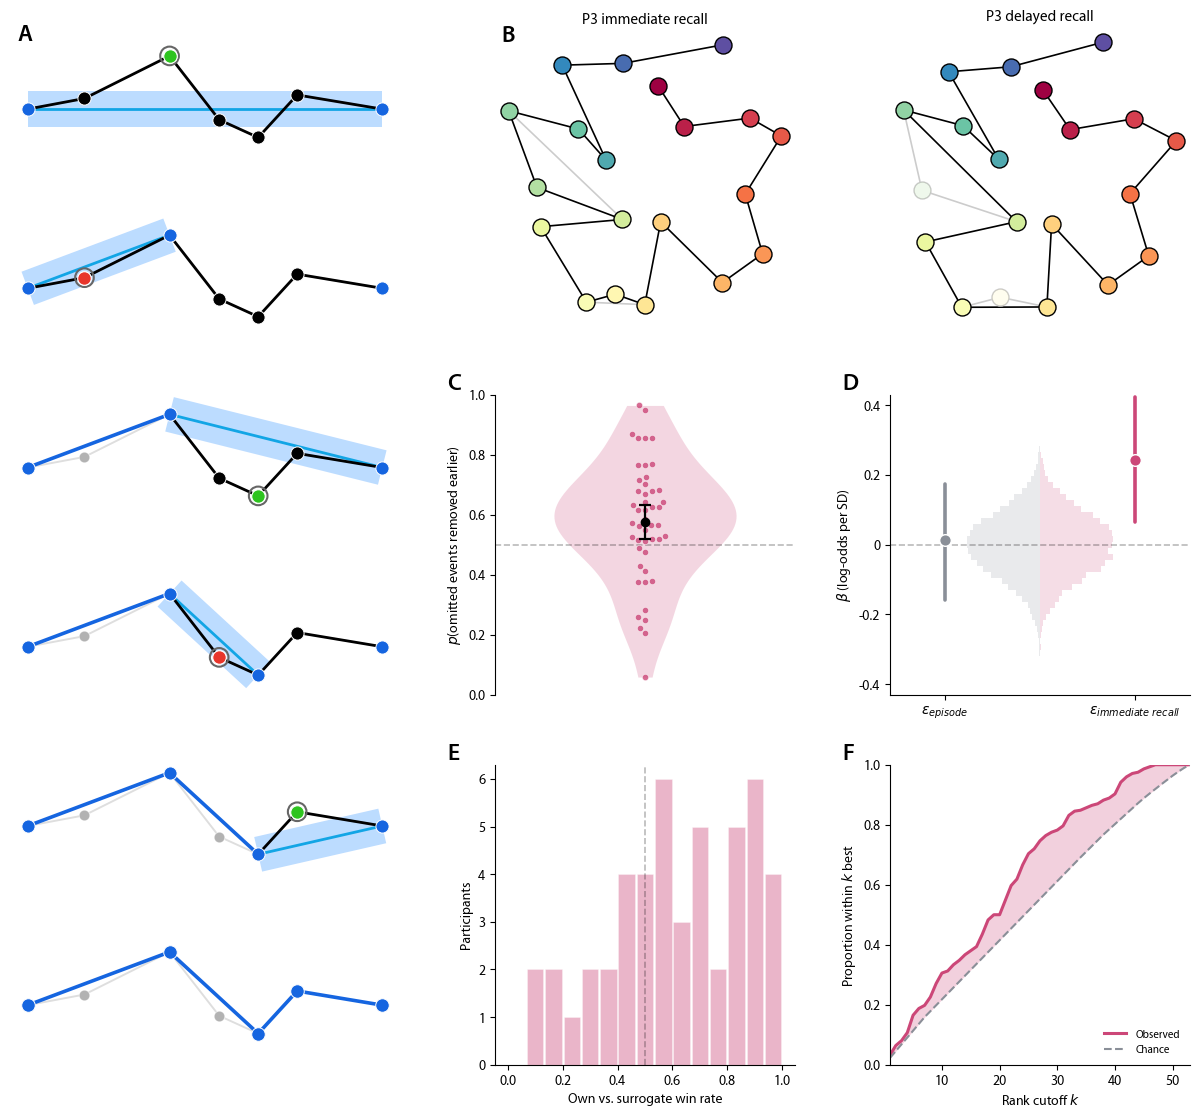

In [23]:
# CONFIG

################################ SHARED ################################
EFFECT_COLOR = '#cc4778'
COMPARE_COLOR = '#8a8f98'
MARKER_EDGE_COLOR = 'white'

REF_LINE_COLOR = 'black'
REF_LINE_ALPHA = 0.27
REF_LINE_LINEWIDTH = 1.2
REF_LINE_LINESTYLE = '--'

# panel letter labels
PANEL_LETTER_COLOR = 'black'
PANEL_LETTER_SIZE = 17
PANEL_LETTER_WEIGHT = 'semibold'
CDEF_LETTER_POS = (-0.16, 1)

# layout (in inches)
PANEL_SIZE = 3.0
GAP_X = 0.95
GAP_Y = 0.70
MARGIN = 0.40
CARTOON_WIDTH = 1.3 * PANEL_SIZE
STACK_HEIGHT = 3 * PANEL_SIZE + 2 * GAP_Y

############################# RDP CARTOON ##############################
CARTOON_PATH = np.array([
    [0.00, 0.50], 
    [0.16, 0.53], 
    [0.40, 0.65], 
    [0.54, 0.47],
    [0.65, 0.42], 
    [0.76, 0.54], 
    [1.00, 0.50]
])
CARTOON_EPS = 0.05
CARTOON_PAD_LEFT = 0.05
CARTOON_PAD_RIGHT = 0.05
CARTOON_ROW_MARGIN_FRAC = 0.03
# colors
CARTOON_CURVE_COLOR = 'black'
CARTOON_ENDPOINT_COLOR = '#1565e0'
CARTOON_CHORD_COLOR = '#12a5e5'
CARTOON_KEEP_COLOR = '#2ec41f'
CARTOON_DROP_COLOR = '#e8352b'
CARTOON_RING_COLOR = '#666'
CARTOON_BAND_COLOR = '#409bff'
CARTOON_GHOST_COLOR = 'black'
CARTOON_FAINT_COLOR = 'black'
# alphas
CARTOON_BAND_ALPHA = 0.35
CARTOON_GHOST_ALPHA = 0.30
CARTOON_FAINT_ALPHA = 0.13
# marker sizes
CARTOON_POINT_SIZE = 90
CARTOON_FINAL_POINT_SIZE = 95
CARTOON_GHOST_SIZE = 55
CARTOON_RING_SIZE = 180
CARTOON_RING_INNER_SIZE = 95
# line widths
CARTOON_CURVE_LW = 2.0
CARTOON_SIMPLIFIED_LW = 2.6
CARTOON_FAINT_LW = 1.4
CARTOON_CHORD_LW = 2.0
CARTOON_POINT_EDGE_LW = 0.7
CARTOON_GHOST_EDGE_LW = 0.6
CARTOON_RING_LW = 1.5
CARTOON_RING_INNER_EDGE_LW = 0.8
CARTOON_LABEL_POS = (0.02, 0.98)

######################### EXAMPLE PARTICIPANT ##########################
EXAMPLE_PARTICIPANT_N = 3
EXAMPLE_PATH_COLOR = 'black'
EXAMPLE_PATH_LW = 1.2
EXAMPLE_DROP_LINK_COLOR = 'black'
EXAMPLE_DROP_ALPHA = 0.2
EXAMPLE_DOT_SIZE = 150
EXAMPLE_DOT_EDGE_COLOR = 'black'
EXAMPLE_DOT_EDGE_LW = 1
EXAMPLE_TITLE_FONTSIZE = 11
EXAMPLE_EPISODE_COLORS = plt.cm.Spectral(np.linspace(0, 1, 20))
# events dropped between immediate and delayed recall 
# (note: hard-coded for example participant)
EXAMPLE_IMM_BRIDGES = [(13, 15), (9, 11)]
EXAMPLE_DEL_GHOSTS  = [(10, (9, 10)), (14, (12, 13))]
EXAMPLE_LABEL_POS = (0.02, 0.95)

###################### PROBABILITY OF SUPERIORITY ######################
POS_VIOLIN_WIDTH = 0.85
POS_VIOLIN_ALPHA = 0.22
POS_VIOLIN_EDGE_LW = 0
POS_SWARM_SIZE = 4.5
POS_SWARM_ALPHA = 0.8
POS_SWARM_EDGE_LW = 0.4
POS_CI_COLOR = 'black'
POS_CI_ALPHA = 1.0
POS_CI_MARKER_SIZE = 6
POS_CI_CAPSIZE = 4
POS_CI_LW = 1.6
POS_XLIM = (-0.7, 0.7)
POS_YLIM = (0, 1)

############################## REGRESSION ##############################
REG_NULL_BINS = 41
REG_NULL_HALF_WIDTH = 0.40
REG_NULL_FILL_ALPHA = 0.18
REG_NULL_EDGE_ALPHA = 0.7
REG_NULL_EDGE_LW = 1
REG_OBSERVED_X = 0.52
REG_OBSERVED_LW = 2.6
REG_OBSERVED_DOT_SIZE = 70
REG_OBSERVED_DOT_EDGE_LW = 1
REG_XLIM = (-0.82, 0.82)
REG_YLIM = (-0.43, 0.43)
REG_YTICKS = [-0.4, -0.2, 0, 0.2, 0.4]

############################### WIN RATE ###############################
WINRATE_N_BINS = 15
WINRATE_ALPHA = 0.4
WINRATE_BAR_WIDTH = 0.9
WINRATE_EDGE_LW = 0.5

############################# TOP-K CURVE ##############################
RANK_OBSERVED_LW = 2.2
RANK_CHANCE_LW = 1.5
RANK_FILL_ALPHA = 0.25
RANK_LEGEND_FONTSIZE = 8


# =============================== LAYOUT ===============================
fig_width = 2 * MARGIN + CARTOON_WIDTH + 2 * PANEL_SIZE + 2 * GAP_X
fig_height = 2 * MARGIN + STACK_HEIGHT
fig = plt.figure(figsize=(fig_width, fig_height))

col1_x = MARGIN + CARTOON_WIDTH + GAP_X
col2_x = col1_x + PANEL_SIZE + GAP_X
top_y = MARGIN + STACK_HEIGHT


# ========================= RDP CARTOON PANEL ==========================
ax_cartoon = fig.add_axes(axes_rect(MARGIN, 
                                    MARGIN, 
                                    CARTOON_WIDTH, 
                                    STACK_HEIGHT, 
                                    fig_width, 
                                    fig_height))
draw_rdp_cartoon(ax_cartoon, aspect=CARTOON_WIDTH / STACK_HEIGHT)
add_panel_letter(ax_cartoon, 'A', CARTOON_LABEL_POS)


# ===================== EXAMPLE PARTICIPANT PANEL ======================
example_participant = participants[EXAMPLE_PARTICIPANT_N - 1]
example_label = f'P{EXAMPLE_PARTICIPANT_N}'
imm_path = example_participant.paths_2d['atlep1']
imm_matches = example_participant.event_matches['atlep1']
del_path = example_participant.paths_2d['delayed']
del_matches = example_participant.event_matches['delayed']

# immediate recall
ax_imm = fig.add_axes(axes_rect(col1_x, 
                                top_y - PANEL_SIZE, 
                                PANEL_SIZE, 
                                PANEL_SIZE, 
                                fig_width, 
                                fig_height))
ax_imm.plot(imm_path[:, 0], 
            imm_path[:, 1], 
            '-', 
            color=EXAMPLE_PATH_COLOR, 
            linewidth=EXAMPLE_PATH_LW, 
            zorder=1)

for before, after in EXAMPLE_IMM_BRIDGES:
    start, end = imm_path[before - 1], imm_path[after - 1]
    ax_imm.plot([start[0], end[0]], 
                [start[1], end[1]], 
                '-', 
                color=EXAMPLE_DROP_LINK_COLOR,
                alpha=EXAMPLE_DROP_ALPHA, 
                linewidth=EXAMPLE_PATH_LW, 
                zorder=1)

for i in range(len(imm_path)):
    draw_event_dot(ax_imm, imm_path[i], imm_matches[i])

ax_imm.set_aspect('equal')
ax_imm.axis('off')
ax_imm.set_title(f'{example_label} immediate recall', 
                 fontsize=EXAMPLE_TITLE_FONTSIZE)
add_panel_letter(ax_imm, 'B', EXAMPLE_LABEL_POS)

# delayed recall
ax_del = fig.add_axes(axes_rect(col2_x, 
                                top_y - PANEL_SIZE, 
                                PANEL_SIZE, 
                                PANEL_SIZE, 
                                fig_width, 
                                fig_height))
ax_del.plot(del_path[:, 0], 
            del_path[:, 1], 
            '-', 
            color=EXAMPLE_PATH_COLOR, 
            linewidth=EXAMPLE_PATH_LW, 
            zorder=1)

for imm_ix, (del_before, del_after) in EXAMPLE_DEL_GHOSTS:
    ghost_xy = imm_path[imm_ix - 1]
    for del_ix in (del_before, del_after):
        neighbour = del_path[del_ix - 1]
        ax_del.plot([ghost_xy[0], neighbour[0]], 
                    [ghost_xy[1], neighbour[1]], 
                    '-',
                    color=EXAMPLE_DROP_LINK_COLOR, 
                    alpha=EXAMPLE_DROP_ALPHA, 
                    linewidth=EXAMPLE_PATH_LW, 
                    zorder=1)
    
    ax_del.scatter(ghost_xy[0], 
                   ghost_xy[1], 
                   s=EXAMPLE_DOT_SIZE, 
                   facecolor='white',
                   edgecolor='white', 
                   lw=EXAMPLE_DOT_EDGE_LW, 
                   zorder=1.5)
    draw_event_dot(ax_del, 
                   ghost_xy, 
                   imm_matches[imm_ix - 1], 
                   alpha=EXAMPLE_DROP_ALPHA, 
                   zorder=2)

for i in range(len(del_path)):
    draw_event_dot(ax_del, del_path[i], del_matches[i])

ax_del.set_aspect('equal')
ax_del.axis('off')
ax_del.set_title(f'{example_label} delayed recall', 
                 fontsize=EXAMPLE_TITLE_FONTSIZE)


# ================== PROBABILITY OF SUPERIORITY PANEL ==================
ax_pos = fig.add_axes(axes_rect(col1_x, 
                                top_y - 2 * PANEL_SIZE - GAP_Y, 
                                PANEL_SIZE, 
                                PANEL_SIZE, 
                                fig_width, 
                                fig_height))
violin = ax_pos.violinplot([participants_pos], 
                           positions=[0], 
                           vert=True,
                           showextrema=False, 
                           widths=POS_VIOLIN_WIDTH)
for body in violin['bodies']:
    body.set_facecolor(EFFECT_COLOR)
    body.set_alpha(POS_VIOLIN_ALPHA)
    body.set_edgecolor(EFFECT_COLOR)
    body.set_linewidth(POS_VIOLIN_EDGE_LW)

sns.swarmplot(y=participants_pos, 
              size=POS_SWARM_SIZE,
              color=EFFECT_COLOR, 
              alpha=POS_SWARM_ALPHA, 
              edgecolor=MARKER_EDGE_COLOR, 
              linewidth=POS_SWARM_EDGE_LW, 
              zorder=3, 
              ax=ax_pos)
ax_pos.axhline(0.5, 
               color=REF_LINE_COLOR, 
               alpha=REF_LINE_ALPHA, 
               linestyle=REF_LINE_LINESTYLE, 
               linewidth=REF_LINE_LINEWIDTH)
ax_pos.errorbar([0], 
                [participants_pos.mean()],
                yerr=[[participants_pos.mean() - pos_mean_ci_low],
                      [pos_mean_ci_high - participants_pos.mean()]],
                fmt='o', 
                color=POS_CI_COLOR, 
                alpha=POS_CI_ALPHA, 
                markersize=POS_CI_MARKER_SIZE, 
                capsize=POS_CI_CAPSIZE,
                elinewidth=POS_CI_LW, 
                capthick=POS_CI_LW, 
                zorder=5)
ax_pos.set_ylabel(r'$p$(omitted events removed earlier)')
ax_pos.set_xticks([])
ax_pos.set_xlim(*POS_XLIM)
ax_pos.set_ylim(*POS_YLIM)
ax_pos.spines[['top', 'right', 'bottom']].set_visible(False)
add_panel_letter(ax_pos, 'C', CDEF_LETTER_POS)


# ========================== REGRESSION PANEL ==========================
ax_reg = fig.add_axes(axes_rect(col2_x, 
                                top_y - 2 * PANEL_SIZE - GAP_Y, 
                                PANEL_SIZE, 
                                PANEL_SIZE, 
                                fig_width, 
                                fig_height))

# permutation null distribution
null_bin_edges = np.linspace(min(own_null.min(), episode_null.min()),
                             max(own_null.max(), episode_null.max()), 
                             REG_NULL_BINS + 1)
draw_regression_null(ax_reg, own_null, null_bin_edges, 1, EFFECT_COLOR)
draw_regression_null(ax_reg, episode_null, null_bin_edges, -1, COMPARE_COLOR)
ax_reg.axhline(0, 
               color=REF_LINE_COLOR, 
               alpha=REF_LINE_ALPHA, 
               linestyle=REF_LINE_LINESTYLE, 
               linewidth=REF_LINE_LINEWIDTH)

# observed coefs + 95% CIs
ax_reg.plot([REG_OBSERVED_X, REG_OBSERVED_X], 
            [own_coef_ci_low, own_coef_ci_high],
            color=EFFECT_COLOR, 
            linewidth=REG_OBSERVED_LW, 
            solid_capstyle='round')
ax_reg.scatter([REG_OBSERVED_X], 
               [b_own_z], 
               s=REG_OBSERVED_DOT_SIZE, 
               color=EFFECT_COLOR,
               edgecolor=MARKER_EDGE_COLOR, 
               linewidth=REG_OBSERVED_DOT_EDGE_LW, 
               zorder=4)
ax_reg.plot([-REG_OBSERVED_X, -REG_OBSERVED_X], 
            [episode_coef_ci_low, episode_coef_ci_high],
            color=COMPARE_COLOR, 
            linewidth=REG_OBSERVED_LW, 
            solid_capstyle='round')
ax_reg.scatter([-REG_OBSERVED_X], 
               [b_episode_z], 
               s=REG_OBSERVED_DOT_SIZE, 
               color=COMPARE_COLOR, 
               edgecolor=MARKER_EDGE_COLOR, 
               linewidth=REG_OBSERVED_DOT_EDGE_LW, 
               zorder=4)

ax_reg.set_xlim(*REG_XLIM)
ax_reg.set_ylim(*REG_YLIM)
ax_reg.set_yticks(REG_YTICKS)
ax_reg.set_yticklabels([str(t) for t in REG_YTICKS])
ax_reg.set_xticks([-REG_OBSERVED_X, REG_OBSERVED_X])
ax_reg.set_xticklabels([r'$\epsilon_{episode}$', 
                        r'$\epsilon_{immediate\ recall}$'])
ax_reg.set_ylabel(r'$\beta$ (log-odds per SD)')
ax_reg.spines[['top', 'right']].set_visible(False)
add_panel_letter(ax_reg, 'D', CDEF_LETTER_POS)


# =========================== WIN RATE PANEL ===========================
ax_winrate = fig.add_axes(axes_rect(col1_x, 
                                    MARGIN, 
                                    PANEL_SIZE, 
                                    PANEL_SIZE, 
                                    fig_width, 
                                    fig_height))
ax_winrate.hist(own_win_rates, 
                bins=np.linspace(0, 1, WINRATE_N_BINS + 1), 
                color=EFFECT_COLOR,
                alpha=WINRATE_ALPHA, 
                edgecolor=MARKER_EDGE_COLOR, 
                linewidth=WINRATE_EDGE_LW, 
                rwidth=WINRATE_BAR_WIDTH)
ax_winrate.axvline(0.5, 
                   color=REF_LINE_COLOR, 
                   alpha=REF_LINE_ALPHA, 
                   linestyle=REF_LINE_LINESTYLE, 
                   linewidth=REF_LINE_LINEWIDTH)
ax_winrate.set_xlabel('Own vs. surrogate win rate')
ax_winrate.set_ylabel('Participants')
ax_winrate.spines[['top', 'right']].set_visible(False)
add_panel_letter(ax_winrate, 'E', CDEF_LETTER_POS)


# ========================= TOP-K CURVE PANEL ==========================
rank_cutoffs = np.arange(1, len(participants) + 1)
observed_within_k = np.array([
    np.mean(np.clip(k - target_n_losses, 0, target_n_ties + 1) / (target_n_ties + 1))
    for k in rank_cutoffs
])
chance_within_k = np.array([
    np.mean(np.minimum(k, target_n_surrogates + 1) / (target_n_surrogates + 1))
    for k in rank_cutoffs
])
ax_rank = fig.add_axes(axes_rect(col2_x, 
                                 MARGIN, 
                                 PANEL_SIZE, 
                                 PANEL_SIZE, 
                                 fig_width, 
                                 fig_height))
ax_rank.fill_between(rank_cutoffs, 
                     chance_within_k, 
                     observed_within_k,
                     color=EFFECT_COLOR, 
                     alpha=RANK_FILL_ALPHA, 
                     linewidth=0)
ax_rank.plot(rank_cutoffs, 
             observed_within_k, 
             color=EFFECT_COLOR, 
             linewidth=RANK_OBSERVED_LW, 
             label='Observed')
ax_rank.plot(rank_cutoffs, 
             chance_within_k, 
             '--', 
             color=COMPARE_COLOR, 
             linewidth=RANK_CHANCE_LW, 
             label='Chance')

ax_rank.set_xlabel(r'Rank cutoff $k$')
ax_rank.set_ylabel(r'Proportion within $k$ best')
ax_rank.set_xlim(1, len(participants))
ax_rank.set_ylim(0, 1)
ax_rank.legend(fontsize=RANK_LEGEND_FONTSIZE, frameon=False, loc='lower right')
ax_rank.spines[['top', 'right']].set_visible(False)
add_panel_letter(ax_rank, 'F', CDEF_LETTER_POS)

# plt.savefig(FIG_DIR / 'rdp-figure.pdf', bbox_inches='tight')
plt.show()